# Lab 3

In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Questions

#### 1. Consider the hepatitis/pima-indians-diabetes csv file, perform the following date pre-processing.

1.1 Load data in ```pandas```

In [258]:
df = pd.read_csv('hepatitis.csv')
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,male,False,False,False,False,False,False,False,False,False,False,False,1.0,85.0,18.0,4.0,NaN,False,live
1,50,female,False,False,True,False,False,False,False,False,False,False,False,0.9,135.0,42.0,3.5,NaN,False,live
2,78,female,True,False,True,False,False,True,False,False,False,False,False,0.7,96.0,32.0,4.0,NaN,False,live
3,31,female,NaN,True,False,False,False,True,False,False,False,False,False,0.7,46.0,52.0,4.0,80.0,False,live
4,34,female,True,False,False,False,False,True,False,False,False,False,False,1.0,NaN,200.0,4.0,NaN,False,live


1.2 Drop columns that aren't useful

In [259]:
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

1.3 Drop rows with missing values

In [260]:
df = df.dropna()
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
5,34,female,True,False,False,False,False,True,False,False,False,False,False,0.9,95.0,28.0,4.0,75.0,False,live
10,39,female,False,True,False,False,False,False,True,False,False,False,False,1.3,78.0,30.0,4.4,85.0,False,live
11,32,female,True,True,True,False,False,True,True,False,True,False,False,1.0,59.0,249.0,3.7,54.0,False,live
12,41,female,True,True,True,False,False,True,True,False,False,False,False,0.9,81.0,60.0,3.9,52.0,False,live
13,30,female,True,False,True,False,False,True,True,False,False,False,False,2.2,57.0,144.0,4.9,78.0,False,live


1.4 Create dummy variables

In [261]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,antivirals,bilirubin,alk_phosphate,sgot,albumin,protime,histology,sex_male,steroid_True,fatigue_True,malaise_True,anorexia_True,liver_big_True,liver_firm_True,spleen_palpable_True,spiders_True,ascites_True,varices_True,class_live
5,34,False,0.9,95.0,28.0,4.0,75.0,False,0,1,0,0,0,1,0,0,0,0,0,1
10,39,True,1.3,78.0,30.0,4.4,85.0,False,0,0,0,0,0,0,1,0,0,0,0,1
11,32,True,1.0,59.0,249.0,3.7,54.0,False,0,1,1,0,0,1,1,0,1,0,0,1
12,41,True,0.9,81.0,60.0,3.9,52.0,False,0,1,1,0,0,1,1,0,0,0,0,1
13,30,False,2.2,57.0,144.0,4.9,78.0,False,0,1,1,0,0,1,1,0,0,0,0,1


1.5 Take care of missing data (if any remain)

In [262]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df[:] = imputer.fit_transform(df)

df.head()

/tmp/ipykernel_211110/3360029880.py:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df[:] = imputer.fit_transform(df)


,age,antivirals,bilirubin,alk_phosphate,sgot,albumin,protime,histology,sex_male,steroid_True,fatigue_True,malaise_True,anorexia_True,liver_big_True,liver_firm_True,spleen_palpable_True,spiders_True,ascites_True,varices_True,class_live
5,34.0,0.0,0.9,95.0,28.0,4.0,75.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
10,39.0,1.0,1.3,78.0,30.0,4.4,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
11,32.0,1.0,1.0,59.0,249.0,3.7,54.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
12,41.0,1.0,0.9,81.0,60.0,3.9,52.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
13,30.0,0.0,2.2,57.0,144.0,4.9,78.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


1.6 Convert DataFrame to NumPy array

In [263]:
dataset = df.to_numpy()
dataset

array([[34. ,  0. ,  0.9, ...,  0. ,  0. ,  1. ],
       [39. ,  1. ,  1.3, ...,  0. ,  0. ,  1. ],
       [32. ,  1. ,  1. , ...,  0. ,  0. ,  1. ],
       ...,
       [31. ,  0. ,  1.2, ...,  0. ,  0. ,  1. ],
       [53. ,  0. ,  1.5, ...,  0. ,  1. ,  1. ],
       [43. ,  0. ,  1.2, ...,  1. ,  0. ,  0. ]])

1.7 Split into training and testing data

In [264]:
from sklearn.model_selection import train_test_split

X = dataset[:, :-1]
y = dataset[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_train.shape}")

X_train: (64, 19)
X_test: (16, 19)
y_train: (64,)
y_test: (64,)


#### 2. Without using ```scikit-learn```,

##### a. Construct a CSV file with the following attributes: 
- Study time in hours of ML lab course (```X```)
- Score out of 10 (```y```)
- The dataset should contain 10 rows

In [265]:
data = {
    "study_time": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "score": [2, 3, 4, 5, 6, 7, 8, 8, 9, 10]
}

st = pd.DataFrame(data)
st.to_csv("scores.csv", index=False)
st.head()

,study_time,score
0,1,2
1,2,3
2,3,4
3,4,5
4,5,6


##### d. Implement the model using two methods:

- Pedhazur formula (intuitive)

In [266]:
X = st['study_time'].values
y = st['score'].values

n = len(X)

B1_p = ((n * np.sum(X * y)) - (np.sum(X) * np.sum(y))) / \
       ((n * np.sum(X * X)) - (np.sum(X) ** 2))

B0_p = (np.sum(y) - B1_p * np.sum(X)) / n

print("Pedhazur Method")
print(f"B0 = {B0_p}")
print(f"B1 = {B1_p}")

Pedhazur Method
B0 = 1.4
B1 = 0.8727272727272727


- Calculus method (partial derivatives, refer to class notes)

In [267]:
X_mean = np.mean(X)
y_mean = np.mean(y)

B1_c = np.sum((X - X_mean) * (y - y_mean)) / \
       np.sum((X - X_mean) ** 2)

B0_c = y_mean - B1_c * X_mean

print("Calculus Method")
print(f"B0 = {B0_c}")
print(f"B1 = {B1_c}")

Calculus Method
B0 = 1.4000000000000004
B1 = 0.8727272727272727


##### e. Compare the coefficients obtained using both methods and compare them with the analytical solution.

In [268]:
X1 = np.column_stack((np.ones(n), X))
B = np.linalg.inv(X1.T @ X1) @ X1.T @ y

B0_mat = B[0]
B1_mat = B[1]

print("Analytical Solution")
print(f"B0 = {B0_mat}")
print(f"B1 = {B1_mat}")

Analytical Solution
B0 = 1.4000000000000012
B1 = 0.8727272727272728


In [269]:
comparison = pd.DataFrame({
    "method": ["Pedhazur", "Calculus", "Analytical"],
    "B0": [B0_p, B0_c, B0_mat],
    "B1": [B1_p, B1_c, B1_mat]
})

comparison

,method,B0,B1
0,Pedhazur,1.4,0.872727
1,Calculus,1.4,0.872727
2,Analytical,1.4,0.872727


##### c. Create a scatter plot of the data points in red color and plot the graph of ```X``` vs. predicted ```y``` in blue color.

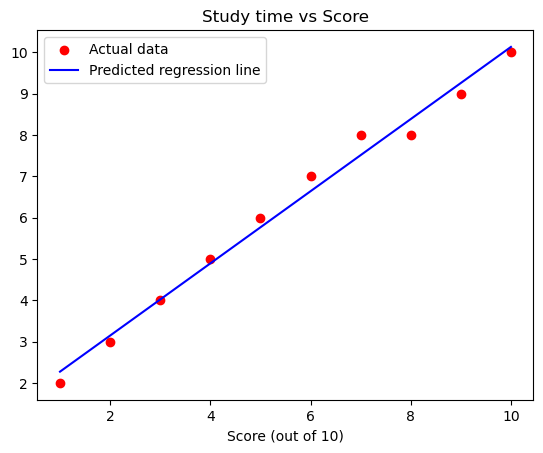

In [270]:
y_pred = B0_c + B1_c * X

plt.scatter(X, y, color='red', label='Actual data')
plt.plot(X, y_pred, color='blue', label='Predicted regression line')

plt.xlabel('Study time (hours)')
plt.xlabel('Score (out of 10)')
plt.title('Study time vs Score')

plt.legend()
plt.show()

##### b. Create a regression model and display the following:

- Coefficients: ```B0``` (intercept) and ```B1``` (slope)

In [271]:
print(f"B0: {B0_c}, B1: {B1_c}")

B0: 1.4000000000000004, B1: 0.8727272727272727


- RMSE (Root Mean Square Error)

In [272]:
rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(f"\nRMSE: {rmse}")


RMSE: 0.2763397118831031


- Predicted responses

In [273]:
pred = pd.DataFrame({
    "study_time": X,
    "predicted_score": y_pred
})

pred

,study_time,predicted_score
0,1,2.272727
1,2,3.145455
2,3,4.018182
3,4,4.890909
4,5,5.763636
5,6,6.636364
6,7,7.509091
7,8,8.381818
8,9,9.254545
9,10,10.127273


##### f. Test your model to predict the score obtained when the study time of a student is 10 hours.

In [274]:
time = 10
pred_X = B0_c + B1_c * time

print(f"Predicted score for 10 hours: {pred_X}")

Predicted score for 10 hours: 10.127272727272727


## Additional Questions

#### 1. Without using ```scikit-learn```,

##### a. Consider the hepatitis/diabetes CSV file.

In [275]:
df.head()

,age,antivirals,bilirubin,alk_phosphate,sgot,albumin,protime,histology,sex_male,steroid_True,fatigue_True,malaise_True,anorexia_True,liver_big_True,liver_firm_True,spleen_palpable_True,spiders_True,ascites_True,varices_True,class_live
5,34.0,0.0,0.9,95.0,28.0,4.0,75.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
10,39.0,1.0,1.3,78.0,30.0,4.4,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
11,32.0,1.0,1.0,59.0,249.0,3.7,54.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
12,41.0,1.0,0.9,81.0,60.0,3.9,52.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
13,30.0,0.0,2.2,57.0,144.0,4.9,78.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


##### c. Implement the model using two methods:

- Pedhazur formula (intuitive)

In [276]:
X = df['age'].values
y = df['protime'].values

n = len(X)

B1_p = ((n * np.sum(X * y)) - (np.sum(X) * np.sum(y))) / \
       ((n * np.sum(X * X)) - (np.sum(X) ** 2))

B0_p = (np.sum(y) - B1_p * np.sum(X)) / n

print("Pedhazur Method")
print(f"B0 = {B0_p}")
print(f"B1 = {B1_p}")

Pedhazur Method
B0 = 78.57284017553917
B1 = -0.3949668656757251


- Calculus method (partial derivatives, refer to class notes)

In [277]:
X_mean = np.mean(X)
y_mean = np.mean(y)

B1_c = np.sum((X - X_mean) * (y - y_mean)) / \
       np.sum((X - X_mean) ** 2)

B0_c = y_mean - B1_c * X_mean

print("Calculus Method")
print(f"B0 = {B0_c}")
print(f"B1 = {B1_c}")

Calculus Method
B0 = 78.57284017553917
B1 = -0.39496686567572503


##### b. Create a scatter plot of the data points in red color and plot the graph of ```X``` vs. predicted ```y``` in blue color. 

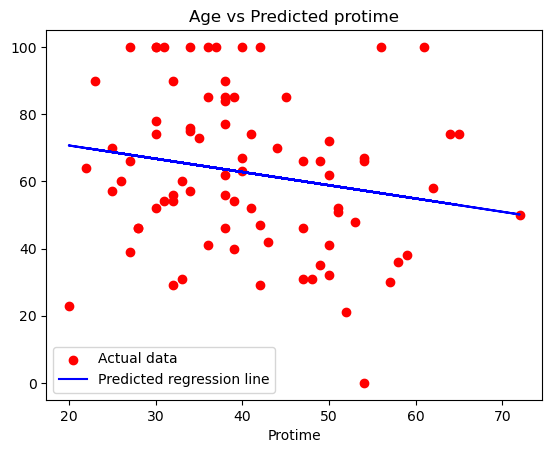

In [278]:
y_pred = B0_c + B1_c * X

plt.scatter(X, y, color='red', label='Actual data')
plt.plot(X, y_pred, color='blue', label='Predicted regression line')

plt.xlabel('Age')
plt.xlabel('Protime')
plt.title('Age vs Predicted protime')

plt.legend()
plt.show()

#### Create a regression model and display the following:

- Coefficients: ```B0``` (intercept) and ```B1``` (slope)

In [279]:
print(f"B0: {B0_c}, B1: {B1_c}")

B0: 78.57284017553917, B1: -0.39496686567572503


- RMSE (Root Mean Square Error)

In [280]:
rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(f"\nRMSE: {rmse}")


RMSE: 22.856045387695488


- Predicted responses

In [281]:
pred = pd.DataFrame({
    "age": X,
    "predicted_protime": y_pred
})

pred

,age,predicted_protime
0,34.0,65.143967
1,39.0,63.169132
2,32.0,65.933900
3,41.0,62.379199
4,30.0,66.723834
...,...,...
75,45.0,60.799331
76,49.0,59.219464
77,31.0,66.328867
78,53.0,57.639596


##### d. Compare the coefficients obtained using both methods.

In [282]:
comparison = pd.DataFrame({
    "method": ["Pedhazur", "Calculus"],
    "B0": [B0_p, B0_c],
    "B1": [B1_p, B1_c]
})

comparison

,method,B0,B1
0,Pedhazur,78.57284,-0.394967
1,Calculus,78.57284,-0.394967


#### For a given data point, check the predicted ```y``` value.

In [283]:
u = int(input("X: "))
pred_X = B0_c + B1_c * u

print(f"Predicted protime for {u}: {pred_X}")

Predicted protime for 10: 74.62317151878192
